# Static predisposing variables — composite map figure (Chapter 5)

Builds a single 2x2 figure with the four static predictors aggregated to Slope Units over the whole Aburra Valley:

- **(a)** Slope angle
- **(b)** Curvature
- **(c)** Land use / land cover
- **(d)** Soil type

Design rules requested for the figure:

- no panel titles and no figure title; panels are identified only by the letters (a)-(d) and described in the LaTeX caption;
- legend inside each panel, lower right;
- frame (spines) on all four sides;
- geographic coordinates (lat/lon) labelled only on the left and bottom axes;
- the slope units carry no outline of their own, so the units along the border look exactly like the ones inside;
- the only line drawn on the map is the administrative boundary of the Aburra Valley Metropolitan Area (`amva.geojson`);
- everything in English.

## 1. Libraries and global settings

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ---------------------------------------------------------------- settings
PATH_SU     = 'slope_units_final_mm.gpkg'
PATH_AMVA   = '/home/oisanchezp/Thesis/data/metadata/amva.geojson'
OUT_DIR     = Path('00Figuras/05Seccion')
OUT_NAME    = 'fig_static_variables'

CRS_PLOT    = 'EPSG:4326'   # geographic CRS, so ticks are in degrees
SIMPLIFY_M  = 5             # simplification for DRAWING only (metres); 0 = off
EDGECOLOR   = 'none'        # no outline on the slope units themselves

DRAW_AMVA   = True          # draw the metropolitan-area boundary
AMVA_LW     = 0.8           # its line width
AMVA_COLOR  = 'black'

# curvature classification
CURV_MODE   = 'fixed'       # 'fixed' -> symmetric threshold; 'quantile' -> terciles
CURV_THR    = 0.001         # only used when CURV_MODE == 'fixed'

DROP_EMPTY_CLASSES = True   # hide classes with zero units from the legends

OUT_DIR.mkdir(parents=True, exist_ok=True)
print('geopandas', gpd.__version__)
import shapely; print('shapely  ', shapely.__version__)

geopandas 0.13.2
shapely   2.0.4


## 2. Load the Slope Units

The relevant columns are `slope_mean`, `curva_mean`, `cobertura` and `suelos`.

In [2]:
# list the layers of the GeoPackage (in case there is more than one)
try:
    from pyogrio import list_layers
    print('Layers:', list_layers(PATH_SU))
except Exception:
    import fiona
    print('Layers:', fiona.listlayers(PATH_SU))

su = gpd.read_file(PATH_SU)

print(f'\nSlope Units : {len(su):,}')
print(f'CRS         : {su.crs}')
print(f'Columns     : {list(su.columns)}')
if su.crs is not None and su.crs.is_projected:
    print(f'Area (km2)  : {su.area.sum()/1e6:,.1f}')

Layers: ['slope_units_final_mm']

Slope Units : 61,073
CRS         : EPSG:3116
Columns     : ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'cobertura_cat', 'cobertura', 'n_mm', 'si_no', 'suelos', 'zona_lluvia', 'curva_std_mean', 'curva_std_std', 'cluster_prob', 'geometry']
Area (km2)  : 1,004.5


In [3]:
# ---- DIAGNOSTIC: check the raw values before mapping them to English labels
for col in ['cobertura_cat', 'suelos']:
    print(f'--- {col} (dtype: {su[col].dtype}) ---')
    print(su[col].value_counts(dropna=False).to_string(), '\n')

for col in ['slope_mean', 'curva_mean']:
    print(f'--- {col} ---')
    print(su[col].describe().to_string(), '\n')

print('NaN per column:')
print(su[['slope_mean', 'curva_mean', 'cobertura_cat', 'suelos']].isna().sum().to_string())

--- cobertura_cat (dtype: float64) ---
cobertura_cat
3.0    27176
2.0    17767
1.0    11854
0.0     3744
4.0      437
NaN       95 

--- suelos (dtype: object) ---
suelos
Areno-limoso                       23284
Areno-arcilloso                    17161
Bloques, gravas, arenas y lodos    11751
Limo-arcilloso                      8877 

--- slope_mean ---
count    61073.000000
mean        24.964960
std          8.108616
min         10.001265
25%         18.435254
50%         25.164010
75%         30.909733
max         63.205081 

--- curva_mean ---
count    61073.000000
mean        -0.000295
std          0.001496
min         -0.029367
25%         -0.000769
50%         -0.000075
75%          0.000465
max          0.029461 

NaN per column:
slope_mean        0
curva_mean        0
cobertura_cat    95
suelos            0


## 3. Category labels in English

`cobertura` may come either as numeric codes (0-4) or as the original Spanish strings; both cases are handled. Check the output of the diagnostic cell above and adjust the dictionaries if any value comes out unmapped.

In [4]:
# --- land cover -----------------------------------------------------------
COVER_FROM_CODE = {
    0: 'Continuous urban fabric',
    1: 'Discontinuous urban fabric',
    2: 'Agricultural areas',
    3: 'Forests',
    4: 'Bare and degraded land',
}
COVER_FROM_ES = {
    'Tejido urbano continuo':        'Continuous urban fabric',
    'Tejido urbano discontinuo':     'Discontinuous urban fabric',
    'Territorios agricolas':         'Agricultural areas',
    'Territorios agr\u00edcolas':    'Agricultural areas',
    'Tierras agricolas':             'Agricultural areas',
    'Tierras agr\u00edcolas':        'Agricultural areas',
    'Bosques':                       'Forests',
    'Tierras desnudas y degradadas': 'Bare and degraded land',
}

# --- soil type ------------------------------------------------------------
SOIL_FROM_ES = {
    'Limo-arcilloso':                  'Silty clay',
    'Areno-arcilloso':                 'Sandy clay',
    'Areno-limoso':                    'Sandy silt',
    'Bloques, gravas, arenas y lodos': 'Blocks, gravel, sand and mud',
}


def to_english(series, from_code=None, from_es=None):
    """Translate a categorical column to English, whether it is numeric or text."""
    if pd.api.types.is_numeric_dtype(series) and from_code is not None:
        return series.map(lambda v: from_code.get(int(v)) if pd.notna(v) else np.nan)
    s = series.astype(str).str.strip()
    s = s.where(series.notna(), np.nan)
    return s.map(from_es)



su['cover_en'] = to_english(su['cobertura_cat'], COVER_FROM_CODE, COVER_FROM_ES)
su['soil_en']  = to_english(su['suelos'],    None,             SOIL_FROM_ES)

# report any value that failed to map (excluding genuine NaN in the source)
for src, dst in [('cobertura_cat', 'cover_en'), ('suelos', 'soil_en')]:
    bad = su.loc[su[dst].isna() & su[src].notna(), src].unique()
    if len(bad):
        print(f'WARNING - unmapped values in "{src}": {bad}')
    else:
        print(f'OK - all values of "{src}" were mapped.')

OK - all values of "cobertura_cat" were mapped.
OK - all values of "suelos" were mapped.


## 4. Classification of slope and curvature

**Slope** follows the Servicio Geologico Colombiano (SGC) classes, the same ones used in the previous reports. Slope Units with a mean slope of 10 degrees or less were already removed from this dataset, so the two gentlest classes are expected to be empty.

**Curvature** is continuous and very close to zero, so it is reduced to three interpretable classes. `CURV_MODE = 'fixed'` uses a symmetric threshold (`+/- CURV_THR`); `'quantile'` splits the units into terciles. Check the printed counts and pick the option that gives a readable map.

In [5]:
# ---- slope (SGC classes) -------------------------------------------------
SLOPE_BINS = [-np.inf, 5, 10, 15, 20, 30, 45, np.inf]
SLOPE_CATS = [
    '< 5\u00b0: Flat to gently sloping',
    '5\u201310\u00b0: Sloping',
    '10\u201315\u00b0: Strongly sloping',
    '15\u201320\u00b0: Moderately steep',
    '20\u201330\u00b0: Steep',
    '30\u201345\u00b0: Very steep',
    '> 45\u00b0: Extremely steep',
]
SLOPE_COLS = ['#1a9850', '#a6d96a', '#ffffbf', '#fee08b',
              '#fdae61', '#f46d43', '#a50026']

idx = np.digitize(su['slope_mean'].values, SLOPE_BINS[1:-1], right=False)
su['slope_cls'] = [SLOPE_CATS[i] for i in idx]
su.loc[su['slope_mean'].isna(), 'slope_cls'] = np.nan

print('--- Slope classes ---')
print(su['slope_cls'].value_counts().reindex(SLOPE_CATS, fill_value=0).to_string())

# ---- curvature (three classes) -------------------------------------------
CURV_CATS = ['Concave', 'Planar', 'Convex']
CURV_COLS = ['#4575b4', '#e0e0e0', '#e08214']

if CURV_MODE == 'fixed':
    lo, hi = -CURV_THR, CURV_THR
else:
    lo, hi = su['curva_mean'].quantile([1/3, 2/3]).values
print(f'\nCurvature breaks: lo = {lo:.5f} | hi = {hi:.5f}  (mode: {CURV_MODE})')

v = su['curva_mean'].values
su['curv_cls'] = np.select([v < lo, v > hi], ['Concave', 'Convex'], default='Planar')
su.loc[su['curva_mean'].isna(), 'curv_cls'] = np.nan

print('--- Curvature classes ---')
print(su['curv_cls'].value_counts().reindex(CURV_CATS, fill_value=0).to_string())

--- Slope classes ---
slope_cls
< 5°: Flat to gently sloping        0
5–10°: Sloping                      0
10–15°: Strongly sloping         8363
15–20°: Moderately steep        10186
20–30°: Steep                   24882
30–45°: Very steep              17386
> 45°: Extremely steep            256

Curvature breaks: lo = -0.00100 | hi = 0.00100  (mode: fixed)
--- Curvature classes ---
curv_cls
Concave    12432
Planar     41962
Convex      6679


## 5. Geometry preparation

The slope units are no longer dissolved: the only line on the map is the administrative boundary of the Aburra Valley Metropolitan Area, read from `amva.geojson`. This keeps the units along the border looking exactly like the ones inside.

Geometries are simplified (for drawing only, never for analysis) and reprojected to `EPSG:4326` so that the axis ticks are latitude and longitude.

In [6]:
# ---- 1) metropolitan-area boundary ---------------------------------------
amva = None
if DRAW_AMVA:
    amva = gpd.read_file(PATH_AMVA)
    print(f'AMVA features: {len(amva)} | CRS: {amva.crs}')
    amva = amva.to_crs(su.crs).dissolve()          # single polygon
    amva = amva.to_crs(CRS_PLOT).geometry
    print('AMVA boundary ready.')

# ---- 2) slope units: simplify for drawing, then reproject ----------------
su_plot = su.copy()
if SIMPLIFY_M and su_plot.crs is not None and su_plot.crs.is_projected:
    su_plot['geometry'] = su_plot.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
su_plot = su_plot.to_crs(CRS_PLOT)

# ---- 3) common extent: slope units and boundary together -----------------
b = su_plot.total_bounds
if amva is not None:
    a = amva.total_bounds
    b = [min(b[0], a[0]), min(b[1], a[1]), max(b[2], a[2]), max(b[3], a[3])]
XMIN, YMIN, XMAX, YMAX = b
PADX = (XMAX - XMIN) * 0.01
PADY = (YMAX - YMIN) * 0.03

print(f'Plot CRS: {su_plot.crs.to_string()}')
print(f'Bounds  : lon {XMIN:.3f} to {XMAX:.3f} | lat {YMIN:.3f} to {YMAX:.3f}')

AMVA features: 1 | CRS: EPSG:4326
AMVA boundary ready.
Plot CRS: EPSG:4326
Bounds  : lon -75.719 to -75.221 | lat 5.978 to 6.512


## 6. Panel helper

One function draws one categorical map with the required styling: no title, a letter label in the upper-left corner, legend in the lower right, frame on all four sides, and tick labels only on the left and bottom.

In [7]:
def fmt_lon(x, _):
    hemi = 'W' if x < 0 else 'E'
    return f'{abs(x):.2f}\u00b0 {hemi}'


def fmt_lat(y, _):
    hemi = 'S' if y < 0 else 'N'
    return f'{abs(y):.2f}\u00b0 {hemi}'


def add_panel(ax, gdf, column, categories, colors, label, legend_title,
              legend_loc='lower right', ncol=1, ylabel_rotation=90):
    """Draw one categorical Slope-Unit map into `ax`.

    The slope units are drawn without any edge colour, so the units on the
    border of the study area look identical to the ones inside. The only
    line on the map is the AMVA administrative boundary.
    """
    for cat, col in zip(categories, colors):
        sub = gdf[gdf[column] == cat]
        if len(sub) == 0:
            continue
        sub.plot(ax=ax, color=col, edgecolor=EDGECOLOR, linewidth=0.0, zorder=2)

    if amva is not None:
        amva.boundary.plot(ax=ax, color=AMVA_COLOR, linewidth=AMVA_LW, zorder=5)

    # legend, optionally hiding classes with no units
    pairs = list(zip(categories, colors))
    if DROP_EMPTY_CLASSES:
        pairs = [(c, k) for c, k in pairs if (gdf[column] == c).any()]
    handles = [Patch(facecolor=k, edgecolor='0.35', linewidth=0.4, label=c)
               for c, k in pairs]
    leg = ax.legend(handles=handles, title=legend_title, loc=legend_loc,
                    frameon=True, framealpha=0.95, edgecolor='0.45',
                    ncol=ncol, borderpad=0.6, handlelength=1.3,
                    handleheight=1.0, labelspacing=0.35)
    leg.get_frame().set_linewidth(0.6)
    leg.set_zorder(10)
    leg._legend_box.align = 'left'

    # identical extent in the four panels
    ax.set_xlim(XMIN - PADX, XMAX + PADX)
    ax.set_ylim(YMIN - PADY, YMAX + PADY)

    # frame on all four sides
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.8)
        sp.set_color('black')

    # ticks and labels only on the left and bottom
    ax.tick_params(which='both', direction='out', length=3, width=0.7,
                   top=False, right=False, labeltop=False, labelright=False,
                   bottom=True, left=True, labelbottom=True, labelleft=True,
                   labelsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune='both'))
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
    ax.tick_params(axis='y', rotation=ylabel_rotation)
    for t in ax.get_yticklabels():
        t.set_va('center')
    ax.set_xlabel('')
    ax.set_ylabel('')

    # panel letter, no title
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, fontweight='bold', zorder=10,
            bbox=dict(boxstyle='square,pad=0.30', facecolor='white',
                      edgecolor='0.45', linewidth=0.6))
    return ax

## 7. Composite figure

Drawing 61,000 polygons four times takes a couple of minutes the first time.

Saved to: 00Figuras/05Seccion/fig_static_variables.pdf


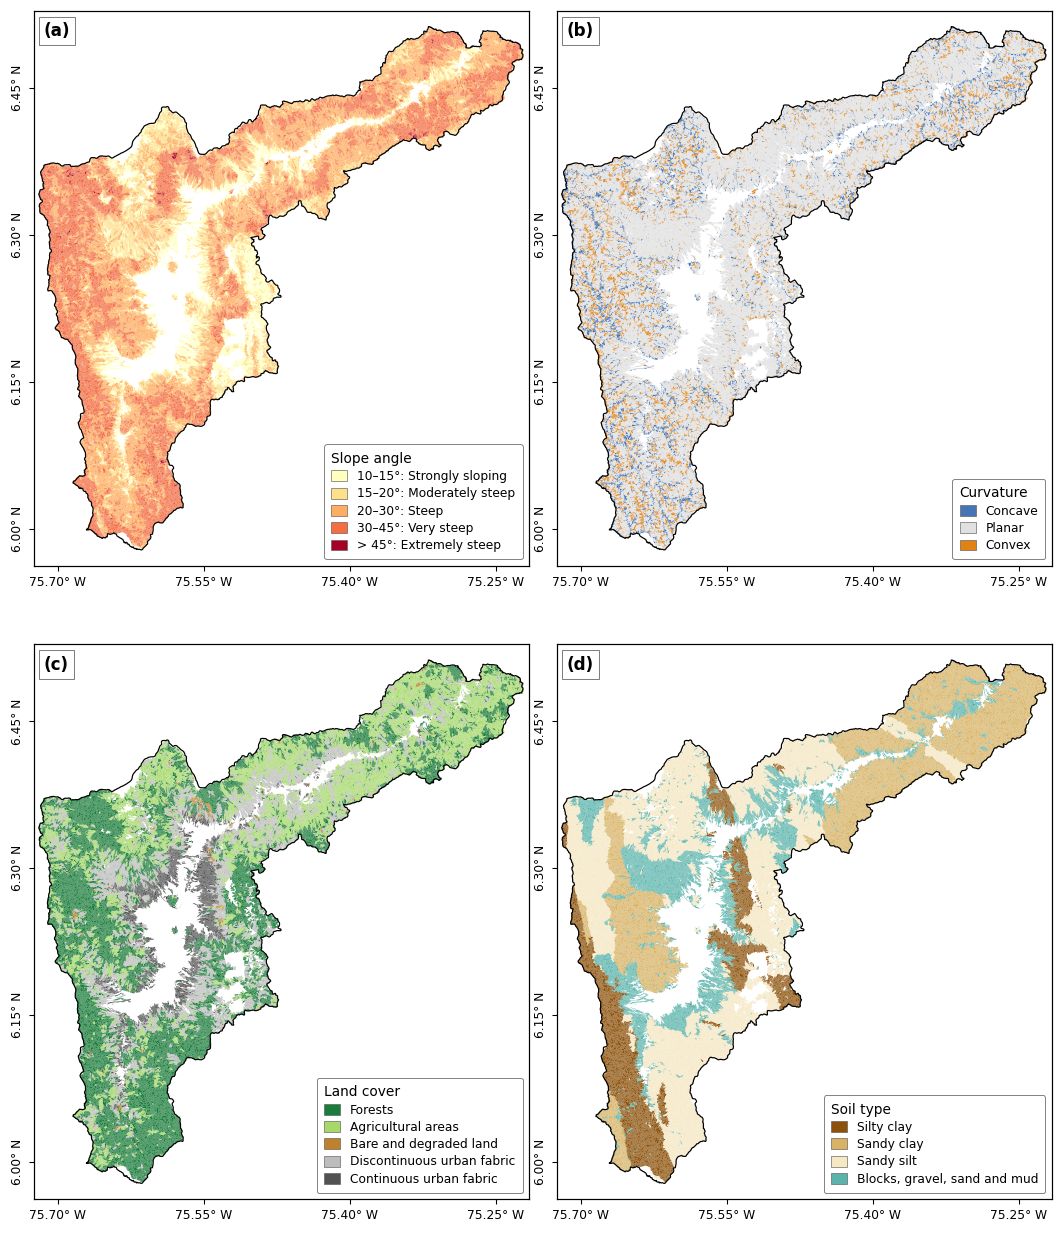

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 11.5), constrained_layout=True)

fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02,
                                wspace=0.01, hspace=0.01)

add_panel(axes[0, 0], su_plot, 'slope_cls', SLOPE_CATS, SLOPE_COLS,
          '(a)', 'Slope angle')

add_panel(axes[0, 1], su_plot, 'curv_cls', CURV_CATS, CURV_COLS,
          '(b)', 'Curvature')

add_panel(axes[1, 0], su_plot, 'cover_en',
          ['Forests', 'Agricultural areas', 'Bare and degraded land',
           'Discontinuous urban fabric', 'Continuous urban fabric'],
          ['#1a7c3a', '#a6d96a', '#bf812d', '#bdbdbd', '#525252'],
          '(c)', 'Land cover')

add_panel(axes[1, 1], su_plot, 'soil_en',
          ['Silty clay', 'Sandy clay', 'Sandy silt',
           'Blocks, gravel, sand and mud'],
          ['#8c510a', '#d8b365', '#f6e8c3', '#5ab4ac'],
          '(d)', 'Soil type')

#fig.savefig(OUT_DIR / f'{OUT_NAME}.pdf')
fig.savefig(OUT_DIR / f'{OUT_NAME}.png')
print('Saved to:', (OUT_DIR / OUT_NAME).with_suffix('.pdf'))
plt.show()

## 8. Summary table for the text

Number of Slope Units and percentage per class, ready to quote in Section 5.2.3.

In [9]:
rows = []
for var, col, cats in [('Slope angle', 'slope_cls', SLOPE_CATS),
                       ('Curvature',   'curv_cls',  CURV_CATS),
                       ('Land cover',  'cover_en',
                        ['Forests', 'Agricultural areas', 'Bare and degraded land',
                         'Discontinuous urban fabric', 'Continuous urban fabric']),
                       ('Soil type',   'soil_en',
                        ['Silty clay', 'Sandy clay', 'Sandy silt',
                         'Blocks, gravel, sand and mud'])]:
    counts = su[col].value_counts().reindex(cats, fill_value=0)
    for cat, n in counts.items():
        rows.append({'Variable': var, 'Class': cat, 'Units': int(n),
                     'Percent': round(100 * n / len(su), 1)})

summary = pd.DataFrame(rows)
summary = summary[summary['Units'] > 0].reset_index(drop=True)
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / 'static_variables_summary.csv', index=False)

   Variable                        Class  Units  Percent
Slope angle     10–15°: Strongly sloping   8363     13.7
Slope angle     15–20°: Moderately steep  10186     16.7
Slope angle                20–30°: Steep  24882     40.7
Slope angle           30–45°: Very steep  17386     28.5
Slope angle       > 45°: Extremely steep    256      0.4
  Curvature                      Concave  12432     20.4
  Curvature                       Planar  41962     68.7
  Curvature                       Convex   6679     10.9
 Land cover                      Forests  27176     44.5
 Land cover           Agricultural areas  17767     29.1
 Land cover       Bare and degraded land    437      0.7
 Land cover   Discontinuous urban fabric  11854     19.4
 Land cover      Continuous urban fabric   3744      6.1
  Soil type                   Silty clay   8877     14.5
  Soil type                   Sandy clay  17161     28.1
  Soil type                   Sandy silt  23284     38.1
  Soil type Blocks, gravel, san

## 9. LaTeX snippet

```latex
\begin{figure}[!ht]
    \centering
    \includegraphics[width=0.90\textwidth]{00Figuras/05Seccion/fig_static_variables.pdf}
    \caption{Static predisposing variables aggregated to the $61{,}073$ slope units of the Aburr\'a Valley: (a) mean slope angle, classified following the Servicio Geol\'ogico Colombiano standard; (b) mean terrain curvature, grouped into concave, planar and convex forms; (c) land use and land cover; and (d) soil type. Continuous variables were averaged over the pixels of each slope unit and categorical variables were assigned the most frequent class within the polygon. The black line is the boundary of the Aburr\'a Valley Metropolitan Area.}
    \label{fig:static_variables}
\end{figure}
```